# DSV ChArUco generator (OpenCV)

Upgrade the **production DSV front-panel stencil** (grid + coloured BUST / UNDERBUST / WAIST / HIP lines) by
replacing legacy **F0 / F1 ArUco** markers with **ChArUco boards** for worn-vest calibration.

Use the upgraded stencil in front / back / side captures so the measurement probe can:

1. **Infer height automatically** — ChArUco scale × shoulder-to-floor geometry (or the optional wall ruler)
2. **Snap measurement lines** — coloured stencil lines at bust, underbust, waist, hip (+ hip2)
3. **Calibrate in real mm** — per-panel homography from ChArUco F0 and F1

**Start with Cell 3 (production stencil upgrade).** Outputs land in `assets/dsv_charuco/`.

Pair with [`dsv_measurement_probe.ipynb`](dsv_measurement_probe.ipynb) to validate on real photos.

In [21]:
# Cell 1 — Install (once per kernel)
import subprocess
import sys
from pathlib import Path

_nb_dir = Path.cwd()
ROOT = _nb_dir.parent if _nb_dir.name == "notebooks" else _nb_dir / "Backend" / "cv_spike"
PROBE_REQ = ROOT / "notebooks" / "requirements-probe.txt"

if not PROBE_REQ.is_file():
    raise FileNotFoundError(f"Expected {PROBE_REQ} — cd to Backend/cv_spike/notebooks")

print(f"Python: {sys.executable}")
print(f"Project root: {ROOT}")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", str(PROBE_REQ)])
print("✓ Dependencies ready")

Python: /opt/homebrew/opt/python@3.11/bin/python3.11
Project root: /Users/debargha/Desktop/swaya/Backend/cv_spike
✓ Dependencies ready



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [23]:
# Cell 2 — Config
import json
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

NB_DIR = Path.cwd()
if NB_DIR.name != "notebooks":
    NB_DIR = NB_DIR / "Backend" / "cv_spike" / "notebooks"
ROOT = NB_DIR.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import importlib

import charuco_dsv_lib
importlib.reload(charuco_dsv_lib)

from charuco_dsv_lib import (
    DSVStencilSpec,
    DSVVestSpec,
    HeightRulerSpec,
    LANDMARK_FROM_FLOOR,
    MEASUREMENT_LEVELS,
    analyze_stencil_photo,
    analyze_vest_photo,
    generate_height_ruler,
    generate_vest_panel,
    save_assets,
    synthesize_worn_preview,
    tile_a4_pages,
    upgrade_stencil_with_charuco,
    DSVPrintSpec,
    generate_dsv_print_master,
    pdf_coverage_audit,
)

print(f"charuco_dsv_lib loaded from {charuco_dsv_lib.__file__}")

STENCIL_PATH = ROOT / "assets" / "dsv_charuco" / "stencils" / "dsv_front_panel_stencil_original.jpg"
# Printed width between outer grid edges — measure one proof print and adjust
STENCIL_PANEL_W_MM = 340.0

OUT_DIR = ROOT / "assets" / "dsv_charuco"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- tune these for your print run ---
REFERENCE_HEIGHT_CM = 170.0   # bands placed for this stature (re-print if cohort differs)
PANEL_W_MM = 280.0
PANEL_H_MM = 560.0
PX_PER_MM = 8.0               # render resolution (~200 dpi)
EXPORT_A4_TILES = True

# 45 GSM fabric print size (two separate front/back pieces)
PRINT_PANEL_W_MM = 1000.0     # 100 cm
PRINT_PANEL_H_MM = 1500.0     # 150 cm
PRINT_DPI = 300               # use 600 for print-house ChArUco sharpness

spec = DSVVestSpec(
    panel_w_mm=PANEL_W_MM,
    panel_h_mm=PANEL_H_MM,
    reference_height_cm=REFERENCE_HEIGHT_CM,
    px_per_mm=PX_PER_MM,
)

print("Measurement levels (mm below shoulder anchor):")
for lv in MEASUREMENT_LEVELS:
    print(f"  {lv:10s}  y={spec.level_y_mm(lv):6.1f} mm  floor_frac={LANDMARK_FROM_FLOOR.get(lv, '—')}")

charuco_dsv_lib loaded from /Users/debargha/Desktop/swaya/Backend/cv_spike/notebooks/charuco_dsv_lib.py
Measurement levels (mm below shoulder anchor):
  shoulder    y=   0.0 mm  floor_frac=0.818
  bust        y= 166.6 mm  floor_frac=0.72
  underbust   y= 226.1 mm  floor_frac=0.685
  waist       y= 336.6 mm  floor_frac=0.62
  hip         y= 489.6 mm  floor_frac=0.53


Print at 100% scale so the stencil grid width = 340 mm. Align SHL-L / SHL-R with the wearer's shoulder line.
Measurement lines (panel mm): {'bust': 94.58, 'underbust': 128.43, 'waist': 169.25, 'hip': 243.92, 'hip2': 277.77}
ChArUco slots: ['F0', 'F1']
/Users/debargha/Desktop/swaya/Backend/cv_spike/assets/dsv_charuco/stencils/dsv_front_panel_charuco.png
/Users/debargha/Desktop/swaya/Backend/cv_spike/assets/dsv_charuco/stencils/dsv_front_panel_charuco_spec.json


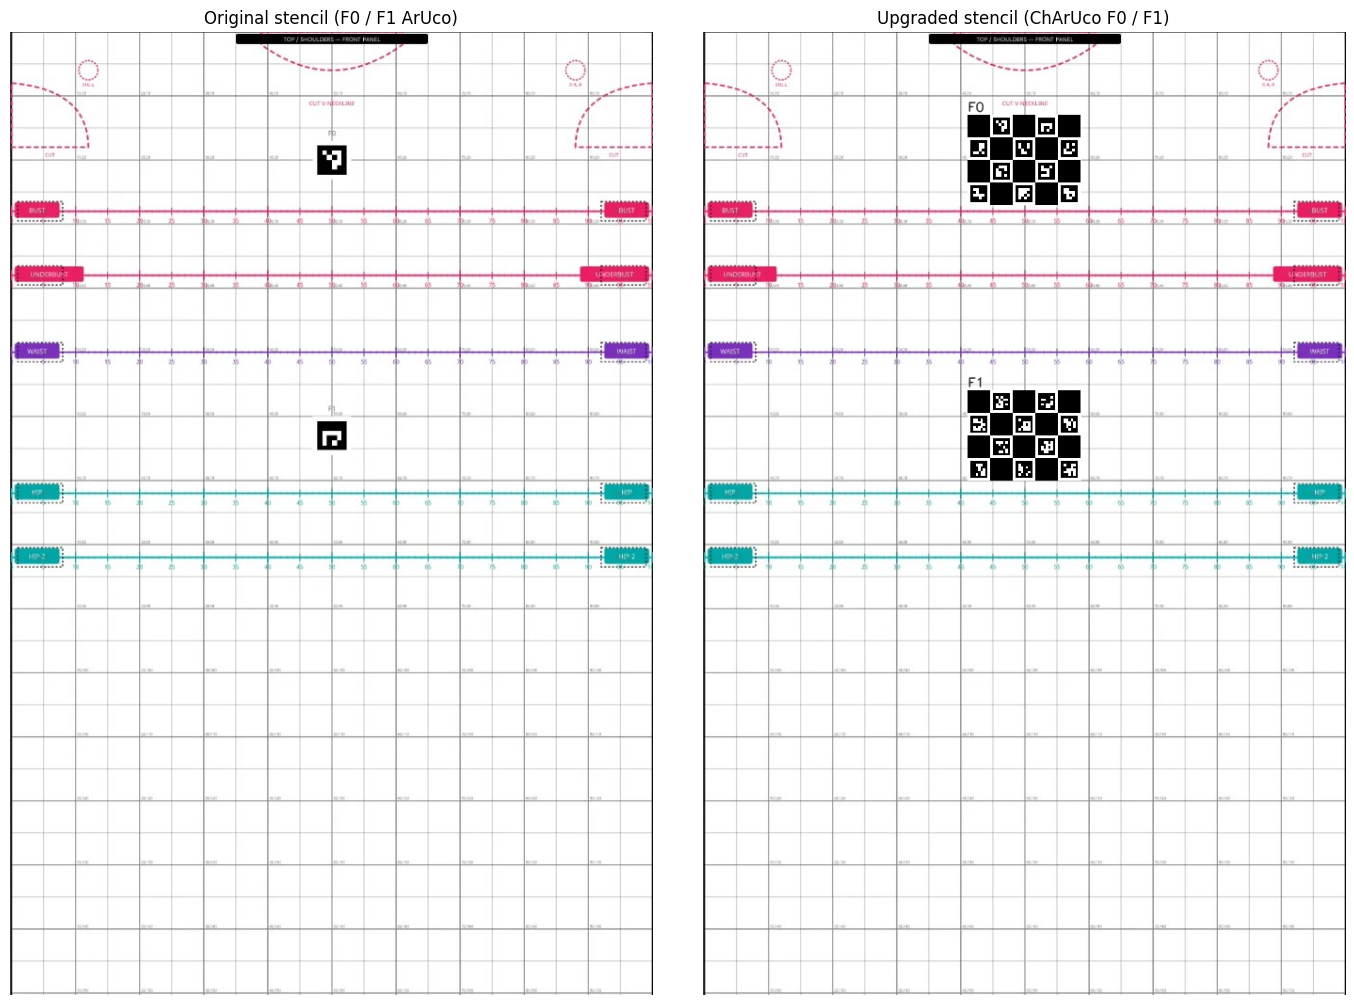

A4 tiles: 4 pages


In [24]:
# Cell 3 — Upgrade production DSV stencil (F0/F1 → ChArUco)
if not STENCIL_PATH.is_file():
    raise FileNotFoundError(f"Place your stencil at {STENCIL_PATH}")

stencil_spec = DSVStencilSpec(
    stencil_path=STENCIL_PATH,
    panel_w_mm=STENCIL_PANEL_W_MM,
)
stencil_assets = upgrade_stencil_with_charuco(stencil_spec)
paths = save_assets(stencil_assets, OUT_DIR / "stencils", basename="dsv_front_panel_charuco")

print(stencil_assets.spec_json["print_note"])
print("Measurement lines (panel mm):", stencil_assets.spec_json["measurement_lines_mm"])
print("ChArUco slots:", list(stencil_assets.spec_json["charuco_slots"].keys()))
for p in paths:
    print(p)

fig, axes = plt.subplots(1, 2, figsize=(14, 10))
orig = cv2.imread(str(STENCIL_PATH))
axes[0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original stencil (F0 / F1 ArUco)")
axes[1].imshow(cv2.cvtColor(stencil_assets.image_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title("Upgraded stencil (ChArUco F0 / F1)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Optional A4 tiles for large-format home printing
if EXPORT_A4_TILES:
    px_per_mm = stencil_assets.spec_json["spec"]["px_per_mm_render"]
    tile_paths = tile_a4_pages(
        stencil_assets.image_bgr, px_per_mm, OUT_DIR / "stencils" / "tiles", prefix="front"
    )
    print(f"A4 tiles: {len(tile_paths)} pages")

PDF functions: yes=2 partial=17 missing=15
Phase-1 launch ready: {'total': 15, 'yes': 2, 'partial': 11, 'missing': 2, 'launch_ready': False}
 • Panel size PDF 100×158 cm vs stencil upgrade 34 cm wide (scale-up now in DSVPrintSpec)
 • PDF 6 cm ArUco F0–F3 vs ChArUco 5×5 boards (upgrade path; panel ID uses board ROI)
 • Back panel F2/F3 not in stencil art — generated programmatically
 • Print 600 DPI — export defaults 300 DPI (set DSVPrintSpec.dpi=600 for print house)
 • Grid 5 cm PDF vs 5 mm in early stencil spec — print master uses 5 cm
TWO SEPARATE 45 GSM fabric pieces:
  1) Print dsv_front_45gsm_300dpi.pdf on sheet 1 — V-neck, ChArUco F0+F1
  2) Print dsv_back_45gsm_300dpi.pdf on sheet 2 — back neckline, ChArUco F2+F3
Settings: 100% scale, NO 'fit to page', media 45 GSM.
Verify each panel (inside crop marks) = 100 cm × 158 cm.
Exported at 300 DPI (11.81 px/mm). Use *_cropmarks.png for alignment; set dpi=600 for print-house.
Front PDF: /Users/debargha/Desktop/swaya/Backend/cv_spike/as

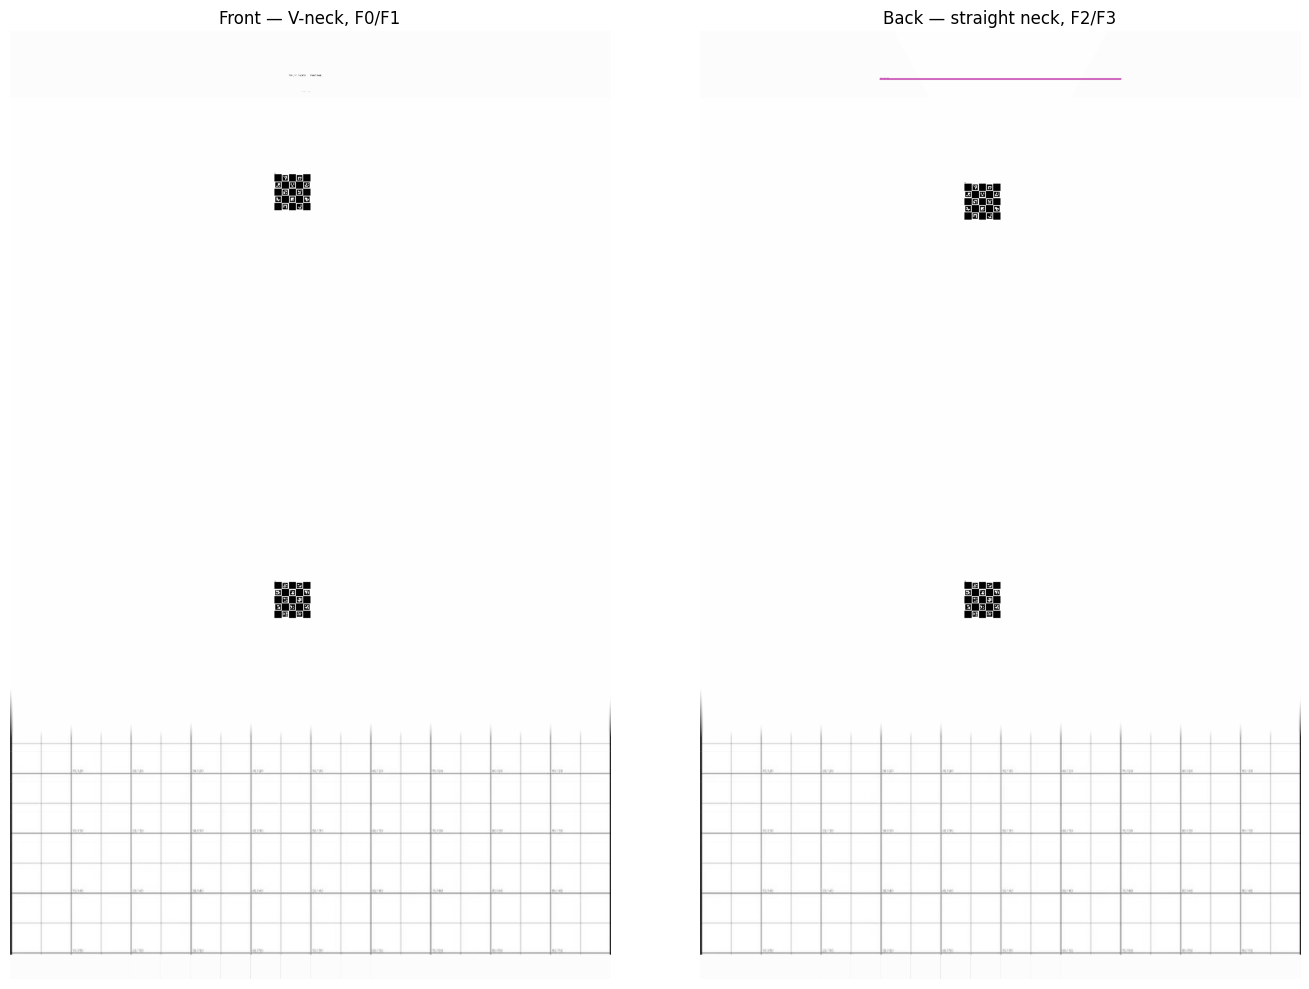

In [25]:
# Cell 3b — PDF coverage audit + 45 GSM print master (100×150 cm @ 300 DPI)
audit = pdf_coverage_audit()
print(f"PDF functions: yes={audit['summary']['yes']} partial={audit['summary']['partial']} missing={audit['summary']['missing']}")
print(f"Phase-1 launch ready: {audit['phase1_launch']}")
for gap in audit["pdf_config_gaps"]:
    print(" •", gap)

print_spec = DSVPrintSpec(
    panel_w_mm=PRINT_PANEL_W_MM,
    panel_h_mm=PRINT_PANEL_H_MM,
    dpi=PRINT_DPI,
    gsm=45,
    render_mode="vector",
    stencil_path=STENCIL_PATH,
    use_charuco=True,
)
print_meta = generate_dsv_print_master(print_spec, OUT_DIR / "print_master")
print(print_meta["print_instructions"])
print("Front PDF:", print_meta["outputs"]["front_pdf"])
print("Back PDF:", print_meta["outputs"]["back_pdf"])
print("Lines (mm):", print_meta["measurement_lines_mm"])

fig, axes = plt.subplots(1, 2, figsize=(14, 10))
for ax, key, title in zip(
    axes,
    ("front_png", "back_png"),
    ("Front — V-neck, F0/F1", "Back — straight neck, F2/F3"),
):
    p = Path(print_meta["outputs"][key])
    thumb = cv2.imread(str(p))
    if thumb is not None:
        h, w = thumb.shape[:2]
        scale = min(1.0, 1400 / w)
        small = cv2.resize(thumb, (int(w * scale), int(h * scale)))
        ax.imshow(cv2.cvtColor(small, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

ChArUco segment dicts: ['DICT_4X4_50', 'DICT_5X5_50', 'DICT_4X4_100', 'DICT_5X5_100', 'DICT_4X4_250', 'DICT_5X5_250', 'DICT_4X4_50', 'DICT_5X5_50', 'DICT_4X4_100', 'DICT_5X5_100']
Ruler tiles: 7
/Users/debargha/Desktop/swaya/Backend/cv_spike/assets/dsv_charuco/height_ruler_200cm.png
Print at 100% scale so height = 200 cm.


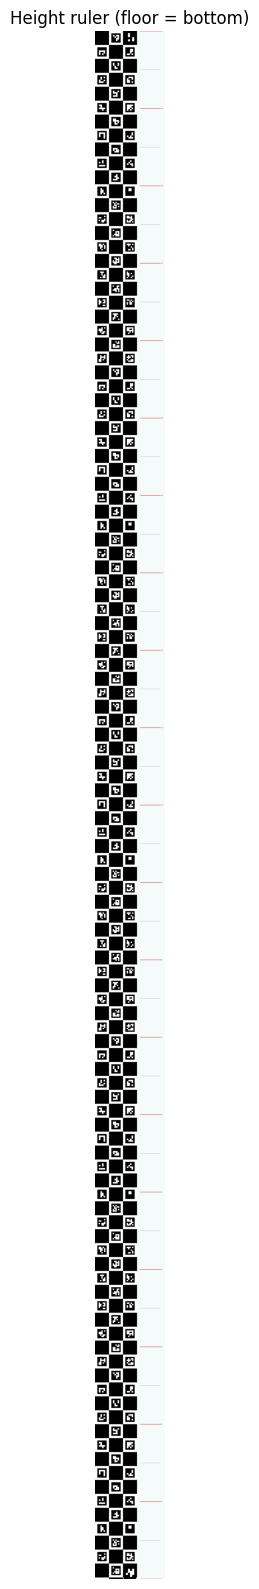

In [27]:
# Cell 4 — Generate height ruler (optional wall chart for stature without self-report)
# Tiled 3×12 ChArUco segments — avoids DICT_4X4_50 id exhaustion on a 200 cm strip.
ruler_spec = HeightRulerSpec(
    height_cm=200.0,
    px_per_mm=PX_PER_MM,
    max_rows_per_board=12,
)
ruler_bgr, ruler_meta = generate_height_ruler(ruler_spec)
print("ChArUco segment dicts:", ruler_meta.get("charuco_dicts_used"))

ruler_png = OUT_DIR / "height_ruler_200cm.png"
cv2.imwrite(str(ruler_png), ruler_bgr)
(OUT_DIR / "height_ruler_spec.json").write_text(json.dumps(ruler_meta, indent=2))

if EXPORT_A4_TILES:
    ruler_tiles = tile_a4_pages(ruler_bgr, ruler_spec.px_per_mm, OUT_DIR / "ruler_tiles", prefix="ruler")
    print(f"Ruler tiles: {len(ruler_tiles)}")

print(ruler_png)
print(ruler_meta["print_note"])

fig, ax = plt.subplots(figsize=(3, 16))
ax.imshow(cv2.cvtColor(ruler_bgr, cv2.COLOR_BGR2RGB))
ax.set_title("Height ruler (floor = bottom)")
ax.axis("off")
plt.tight_layout()
plt.show()

mm_per_px: 0.5
F0 corners: 6
F1 corners: 6
Lines (px): {'bust': 0, 'underbust': 190, 'waist': 339, 'hip': 490, 'hip2': 558}
Lines (mm): {'bust': 0.0, 'underbust': 94.5827232796486, 'waist': 168.75549048316253, 'hip': 243.92386530014642, 'hip2': 277.7745241581259}


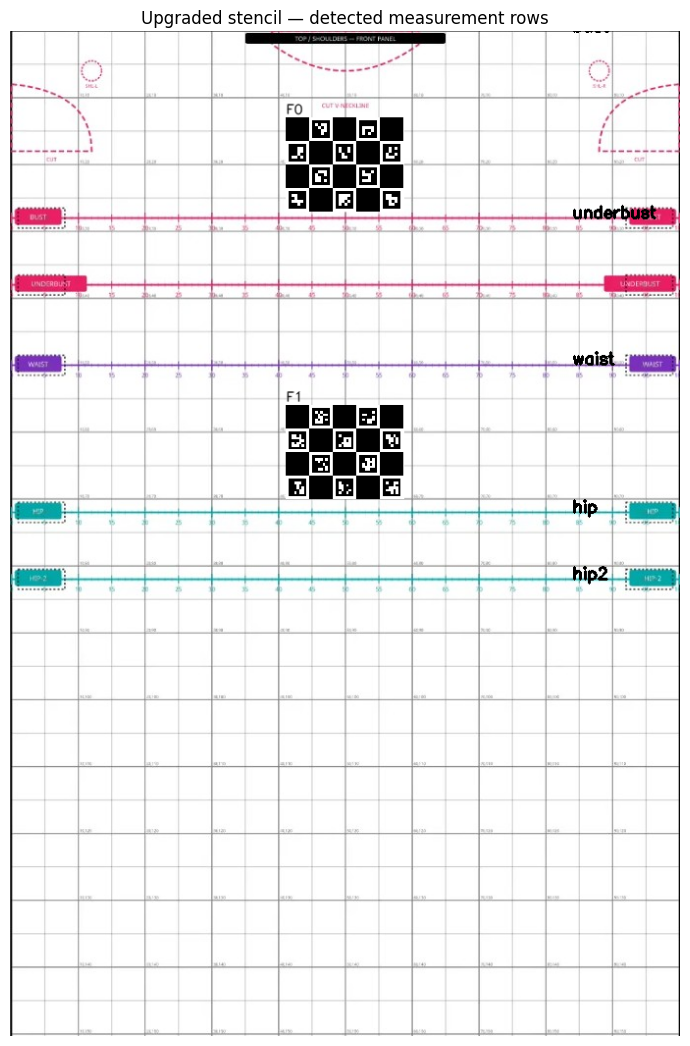

In [28]:
# Cell 5 — Validate ChArUco + measurement lines on upgraded stencil
det = analyze_stencil_photo(stencil_assets.image_bgr, stencil_assets)
print(f"mm_per_px: {det['mm_per_px']}")
print(f"F0 corners: {det['calibrations']['F0']['charuco_corners']}")
print(f"F1 corners: {det['calibrations']['F1']['charuco_corners']}")
print(f"Lines (px): {det['measurement_lines_px']}")
print(f"Lines (mm): {det['measurement_lines_mm']}")
if det["warnings"]:
    print("Warnings:", det["warnings"])

preview = stencil_assets.image_bgr.copy()
for lv, y in det["measurement_lines_px"].items():
    cv2.putText(preview, lv, (preview.shape[1] - 110, y), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 2)

fig, ax = plt.subplots(figsize=(7, 11))
ax.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
ax.set_title("Upgraded stencil — detected measurement rows")
ax.axis("off")
plt.tight_layout()
plt.show()


Perspective test — mm_per_px: None
F0 corners: 0
Lines: {}
Inferred height: None cm


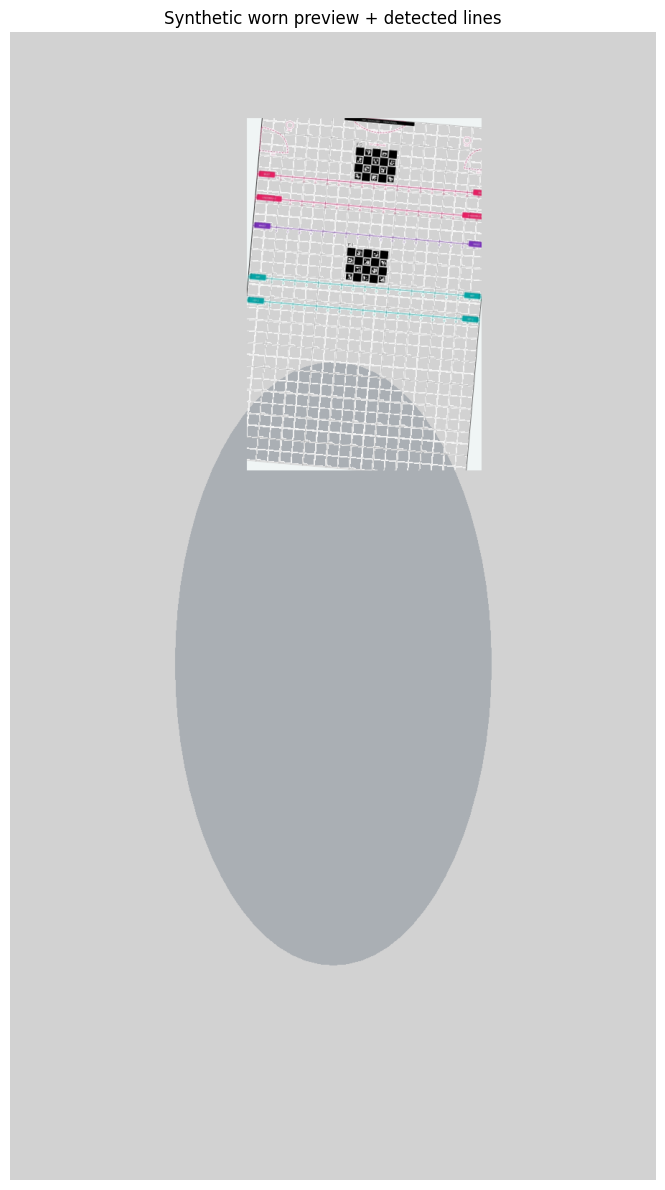

In [29]:
# Cell 6 — Perspective smoke-test (paste panel on a blank torso-shaped canvas)
H, W = 1600, 900
bg = np.full((H, W, 3), 210, np.uint8)
cv2.ellipse(bg, (W // 2, H // 2 + 80), (220, 420), 0, 0, 360, (180, 175, 170), -1)

composite = synthesize_worn_preview(
    stencil_assets.image_bgr,
    bg,
    panel_origin=(W // 2 - 120, 120),
    scale=0.48,
    angle_deg=-5.0,
)
cv2.imwrite(str(OUT_DIR / "stencils" / "synthetic_worn_preview.png"), composite)

det2 = analyze_stencil_photo(composite, stencil_assets, silhouette_bottom_px=H - 40)
print(f"Perspective test — mm_per_px: {det2['mm_per_px']}")
print(f"F0 corners: {det2['calibrations']['F0']['charuco_corners']}")
print(f"Lines: {det2['measurement_lines_px']}")
print(f"Inferred height: {det2['inferred_height_cm']} cm")

fig, ax = plt.subplots(figsize=(7, 12))
ax.imshow(cv2.cvtColor(composite, cv2.COLOR_BGR2RGB))
for lv, y in det2["measurement_lines_px"].items():
    ax.axhline(y, color="white", ls="--", lw=1)
    ax.text(10, y, lv, color="yellow", fontsize=9)
ax.set_title("Synthetic worn preview + detected lines")
ax.axis("off")
plt.tight_layout()
plt.show()

In [30]:
# Cell 7 — Batch: generate panels for multiple reference heights
HEIGHTS_CM = [160, 165, 170, 175, 180]
batch_dir = OUT_DIR / "by_height"
batch_dir.mkdir(parents=True, exist_ok=True)

for h in HEIGHTS_CM:
    s = DSVVestSpec(
        panel_w_mm=PANEL_W_MM,
        panel_h_mm=PANEL_H_MM,
        reference_height_cm=float(h),
        px_per_mm=PX_PER_MM,
    )
    a = generate_vest_panel(s)
    save_assets(a, batch_dir, basename=f"vest_H{h:.0f}")
    print(f"H={h} cm → bust @ {s.level_y_mm('bust'):.1f} mm below shoulder")

print(f"\nBatch written to {batch_dir}")

H=160 cm → bust @ 156.8 mm below shoulder
H=165 cm → bust @ 161.7 mm below shoulder
H=170 cm → bust @ 166.6 mm below shoulder
H=175 cm → bust @ 171.5 mm below shoulder
H=180 cm → bust @ 176.4 mm below shoulder

Batch written to /Users/debargha/Desktop/swaya/Backend/cv_spike/assets/dsv_charuco/by_height


## Print & capture guide

| Asset | Purpose |
|-------|--------|
| `stencils/dsv_front_panel_charuco.png` | Production front panel — **SHL-L/R on shoulder line** |
| `height_ruler_200cm.png` | Optional wall chart for stature |
| `stencils/tiles/` | A4 tiles for home printing |

**Printing**
- Print **100% / actual size**; verify grid width = `STENCIL_PANEL_W_MM` (default 340 mm) with a tape.
- Tune `STENCIL_PANEL_W_MM` in Cell 2 after one proof print.

---

## Feasibility assessment

| Capability | Verdict | Notes |
|------------|---------|-------|
| **Bust / underbust / waist / hip width** | **Feasible (good)** | Coloured stencil lines + ChArUco scale give row anchors and mm/px on the fabric. Works best front & back. |
| **Shoulder width / trapezius** | **Feasible (moderate)** | SHL-L / SHL-R markers + pose; back view preferred. |
| **Automatic height** | **Feasible (moderate)** | Needs full-body framing (feet visible) or wall ruler. ChArUco fixes scale; height = shoulder→floor / 0.818. |
| **Side depth → girth** | **Feasible (moderate)** | Same line colours on side panel + side photo; ellipse girth in `dsv_measurement_probe`. |
| **Worn vest, real world** | **Feasible with caveats** | Fabric curvature, wrinkles, drape, and occlusion reduce accuracy ±1–3 cm vs tape. |

**Why ChArUco over single ArUco (F0/F1)?**
- 10–20 chessboard corners per board → sub-pixel homography vs one 4-corner marker.
- Partial visibility: still calibrates if ≥4 ChArUco corners seen.
- Two boards (F0 upper, F1 lower) bracket the torso — interpolates scale between bust and hip where curvature is worst.

**Main risks**
1. **Print scale drift** — must verify mm width per batch; encode `STENCIL_PANEL_W_MM` in JSON spec.
2. **Vest not aligned to body** — lines slide if shoulder anchor slips; tighten fit at SHL-L/R.
3. **Coloured line collision** — pink bust + underbust are close; probe may need colour clustering (already handled by order + nearest match).
4. **HIP vs HIP2** — garment hem vs anatomical hip; map HIP to girth, HIP2 to hem reference only.

**Bottom line:** The solution is **feasible and materially better** than legacy F0/F1 ArUco for worn-vest CV measurement, especially for line placement and scale. Expect **±1–2 cm** girth accuracy with good capture protocol; tape calibration (`dsv_measurement_probe` sliders + ground truth) still recommended for production tailoring.